In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-17 14:01:49.014033


# Doublet scoring

Run scrublet after light filtering, on individual samples prior to concatenation.

In [2]:
import os
from pathlib import Path
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scrublet as scr
import sys
import anndata as ad
import session_info

In [3]:
plt.rcParams['figure.figsize'] = (3,3)

In [4]:
base_dir = Path('/home/workspace/projects/drg')
input_dirs = {
    "whole": base_dir / "data/h5ad/export_01/03a_pre-filtered/whole",
    "nuclear": base_dir / "data/h5ad/export_01/03b_pre-filtered/nuclear_only",
}
output_dirs = {
    "whole": base_dir / "data/h5ad/export_01/04a_scrublet/whole",
    "nuclear": base_dir / "data/h5ad/export_01/04b_scrublet/nuclear_only",
}
scrublet_dir = base_dir / "scrublet"
scrublet_dir.mkdir(exist_ok=True)

for d in output_dirs.values():
    d.mkdir(parents=True, exist_ok=True)

In [5]:
whole_files = sorted(
    f for f in os.listdir(input_dirs["whole"])
    if f.endswith(".h5ad") and f.startswith("TMA")
)
nuclear_files = sorted(
    f for f in os.listdir(input_dirs["nuclear"])
    if f.endswith(".h5ad") and f.startswith("TMA")
)

whole_adata_list = [
    ad.read_h5ad(input_dirs["whole"] / f).copy()
    for f in whole_files
]
nuclear_adata_list = [
    ad.read_h5ad(input_dirs["nuclear"] / f).copy()
    for f in nuclear_files
]

In [6]:
def run_scrublet(adata_list, scrublet_dir):
    for i, adata in enumerate(adata_list):
        sample_id = adata.obs["output_id"].iloc[0]
        print(f"\nRunning Scrublet for {sample_id}...")

        scrub = scr.Scrublet(adata.X, expected_doublet_rate=0.05)
        doublet_scores, predicted_doublets = scrub.scrub_doublets(
            min_counts=2, 
            min_cells=3, 
            min_gene_variability_pctl=85, 
            n_prin_comps=30
        )

        # Determine threshold
        threshold = scrub.threshold_ if scrub.threshold_ else scrub.doublet_scores_sim_.mean() + 2 * scrub.doublet_scores_sim_.std()
        if scrub.threshold_:
            print(f"Scrublet auto-set threshold for {sample_id}: {threshold:.3f}")
        else:
            print(f"Using fallback threshold for {sample_id}: {threshold:.3f}")

        predicted_doublets = scrub.call_doublets(threshold=threshold)

        # Annotate results
        adata.obs["doublet_scores"] = doublet_scores
        adata.obs["predicted_doublets"] = predicted_doublets

        # Save histogram
        plt.figure(figsize=(10, 6))
        sns.histplot(scrub.doublet_scores_obs_, bins=30, color="blue", label="Observed", kde=True)
        sns.histplot(scrub.doublet_scores_sim_, bins=30, color="red", label="Simulated", kde=True)
        plt.axvline(threshold, color='green', linestyle='--', label=f'Threshold: {threshold:.3f}')
        plt.title(f'Scrublet Doublet Score Distribution for {sample_id}')
        plt.xlabel("Doublet Score")
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Save Scrublet scores
        scrublet_df = pd.DataFrame({
            "Sample_ID": sample_id,
            "Cell_Barcode": adata.obs_names,
            "Doublet_Score": doublet_scores,
            "Predicted_Doublet": predicted_doublets,
        })
        csv_path = scrublet_dir / f"{sample_id}_scrublet_results.csv"
        scrublet_df.to_csv(csv_path, index=False)
        print(f"Saved Scrublet CSV for {sample_id} to {csv_path}")


 Running Scrublet on whole-cell runs

Running Scrublet for TMA00303...
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.29
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.1%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 10.0%
Elapsed time: 5.5 seconds
Scrublet auto-set threshold for TMA00303: 0.294
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.1%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 10.0%


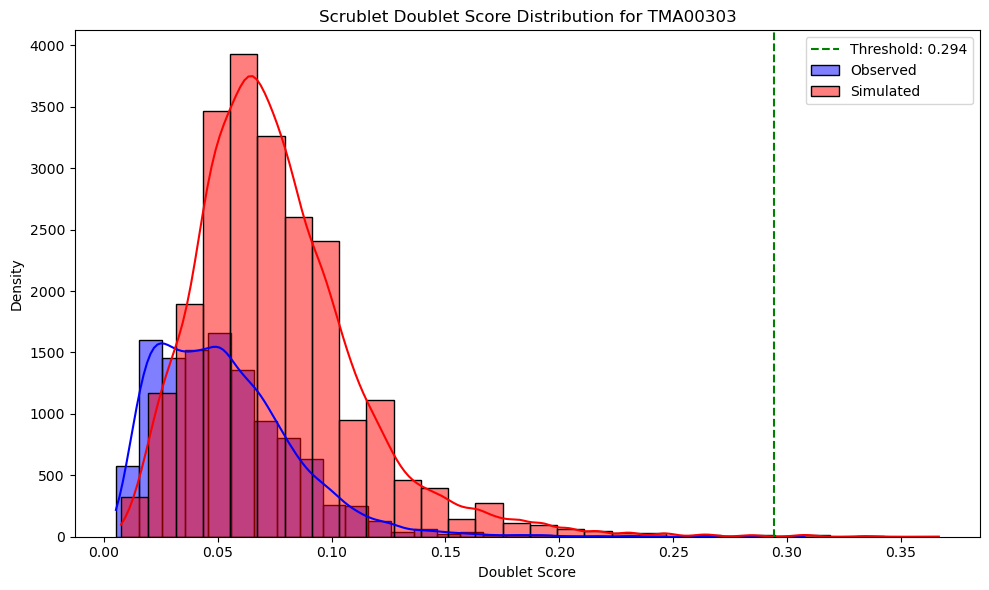

Saved Scrublet CSV for TMA00303 to /home/workspace/projects/drg/scrublet/TMA00303_scrublet_results.csv

Running Scrublet for TMA00304...
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.44
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 100.0%
Elapsed time: 15.2 seconds
Scrublet auto-set threshold for TMA00304: 0.435
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 100.0%


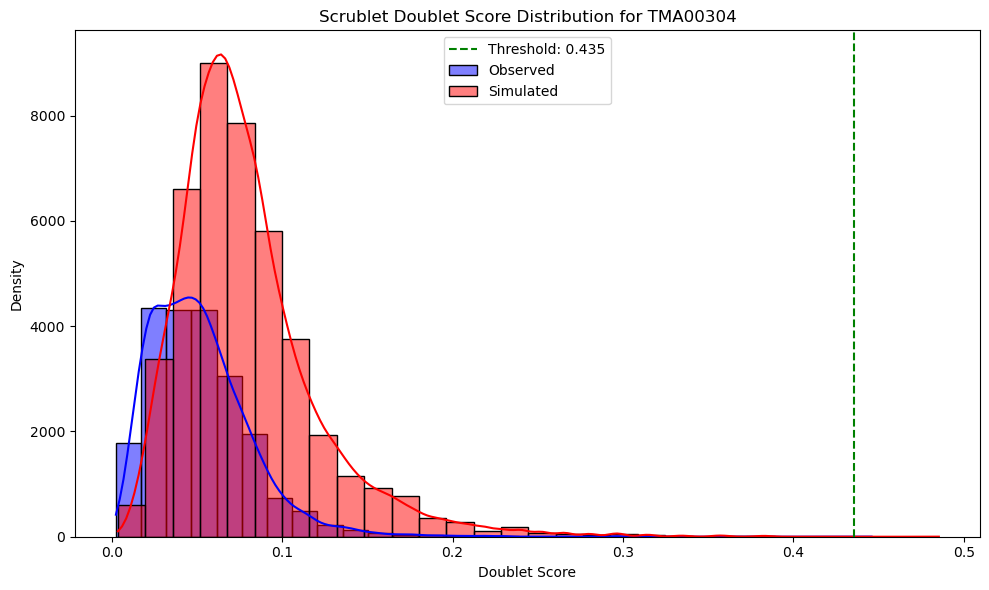

Saved Scrublet CSV for TMA00304 to /home/workspace/projects/drg/scrublet/TMA00304_scrublet_results.csv

Running Scrublet for TMA00305...
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.31
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
Elapsed time: 30.5 seconds
Scrublet auto-set threshold for TMA00305: 0.307
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%


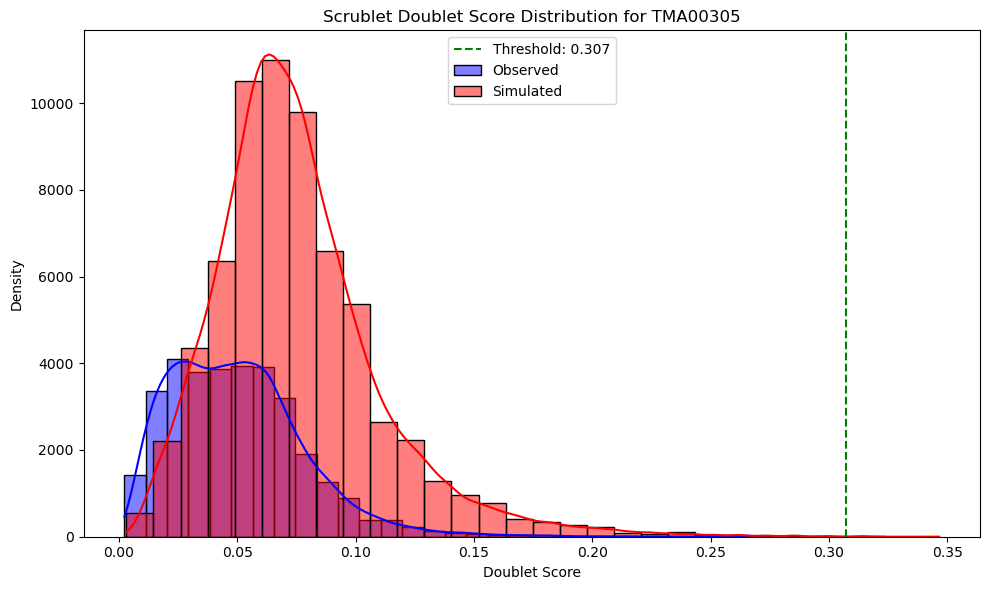

Saved Scrublet CSV for TMA00305 to /home/workspace/projects/drg/scrublet/TMA00305_scrublet_results.csv

Running Scrublet for TMA00306...
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.36
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
Elapsed time: 28.8 seconds
Scrublet auto-set threshold for TMA00306: 0.359
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%


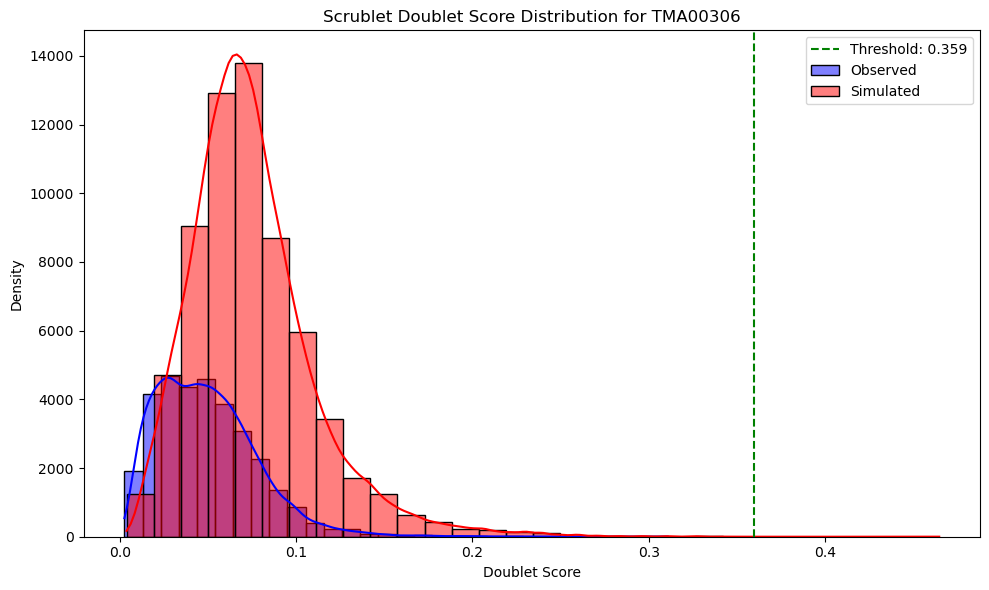

Saved Scrublet CSV for TMA00306 to /home/workspace/projects/drg/scrublet/TMA00306_scrublet_results.csv

 Running Scrublet on nuclear-only runs

Running Scrublet for TMA00303...
Preprocessing...
Simulating doublets...


/home/workspace/environment/sc-scrublet/lib/python3.12/site-packages/scrublet/helper_functions.py:321: RuntimeWarning: divide by zero encountered in divide
  w.setdiag(float(target_total) / tots_use)


Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.34
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
Elapsed time: 5.7 seconds
Scrublet auto-set threshold for TMA00303: 0.343
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%


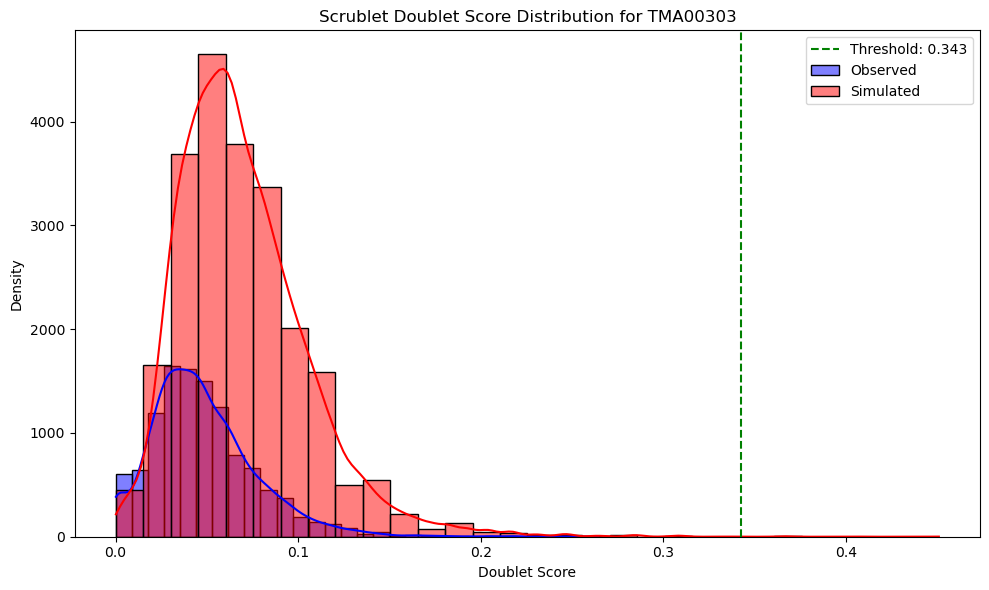

Saved Scrublet CSV for TMA00303 to /home/workspace/projects/drg/scrublet/TMA00303_scrublet_results.csv

Running Scrublet for TMA00304...
Preprocessing...


/home/workspace/environment/sc-scrublet/lib/python3.12/site-packages/scrublet/helper_functions.py:321: RuntimeWarning: divide by zero encountered in divide
  w.setdiag(float(target_total) / tots_use)


Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.43
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 11.1%
Elapsed time: 14.8 seconds
Scrublet auto-set threshold for TMA00304: 0.428
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 11.1%


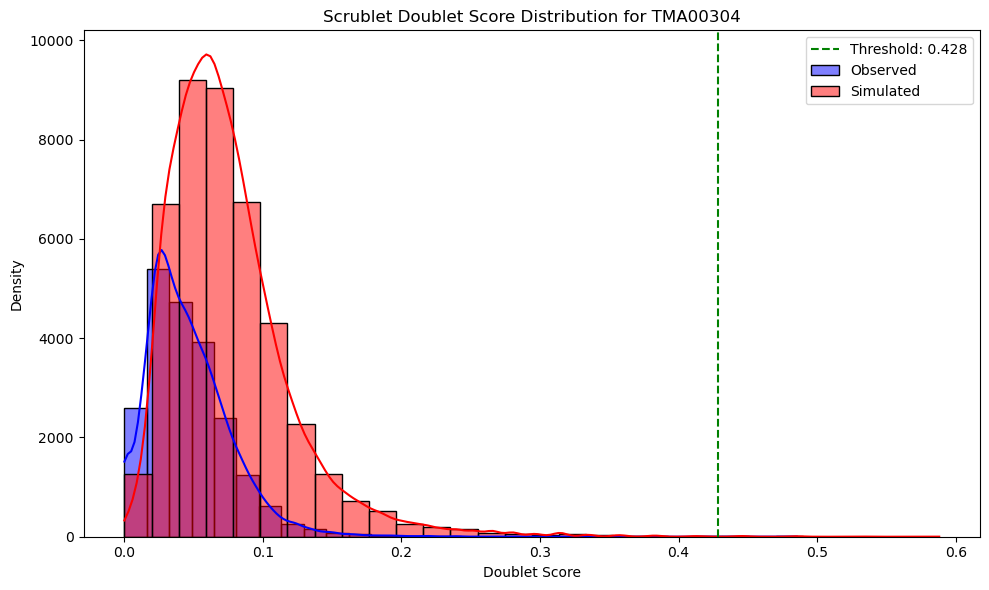

Saved Scrublet CSV for TMA00304 to /home/workspace/projects/drg/scrublet/TMA00304_scrublet_results.csv

Running Scrublet for TMA00305...
Preprocessing...


/home/workspace/environment/sc-scrublet/lib/python3.12/site-packages/scrublet/helper_functions.py:321: RuntimeWarning: divide by zero encountered in divide
  w.setdiag(float(target_total) / tots_use)


Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.48
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
Elapsed time: 29.8 seconds
Scrublet auto-set threshold for TMA00305: 0.478
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%


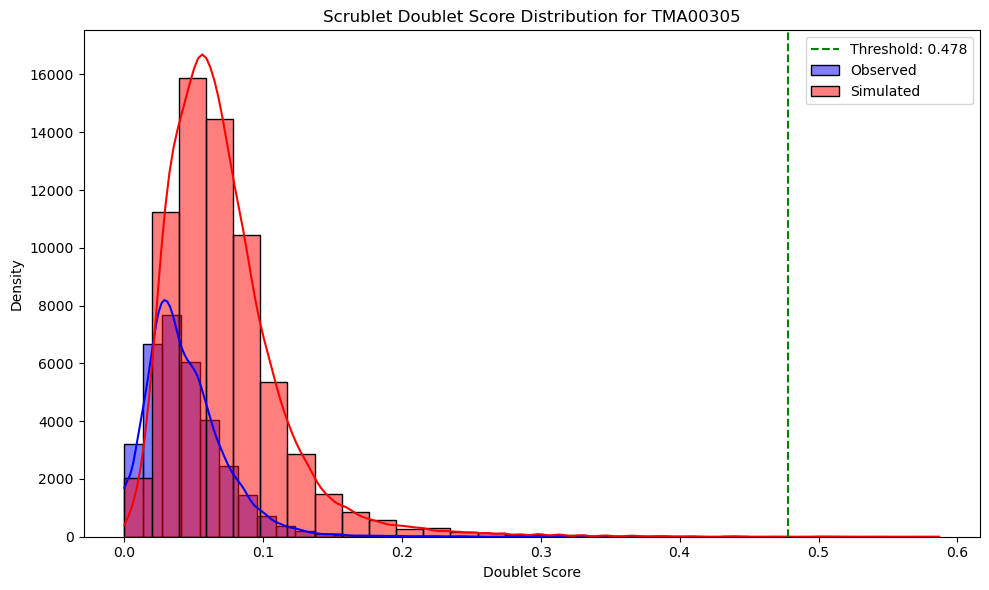

Saved Scrublet CSV for TMA00305 to /home/workspace/projects/drg/scrublet/TMA00305_scrublet_results.csv

Running Scrublet for TMA00306...
Preprocessing...


/home/workspace/environment/sc-scrublet/lib/python3.12/site-packages/scrublet/helper_functions.py:321: RuntimeWarning: divide by zero encountered in divide
  w.setdiag(float(target_total) / tots_use)


Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.26
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
Elapsed time: 29.7 seconds
Scrublet auto-set threshold for TMA00306: 0.265
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%


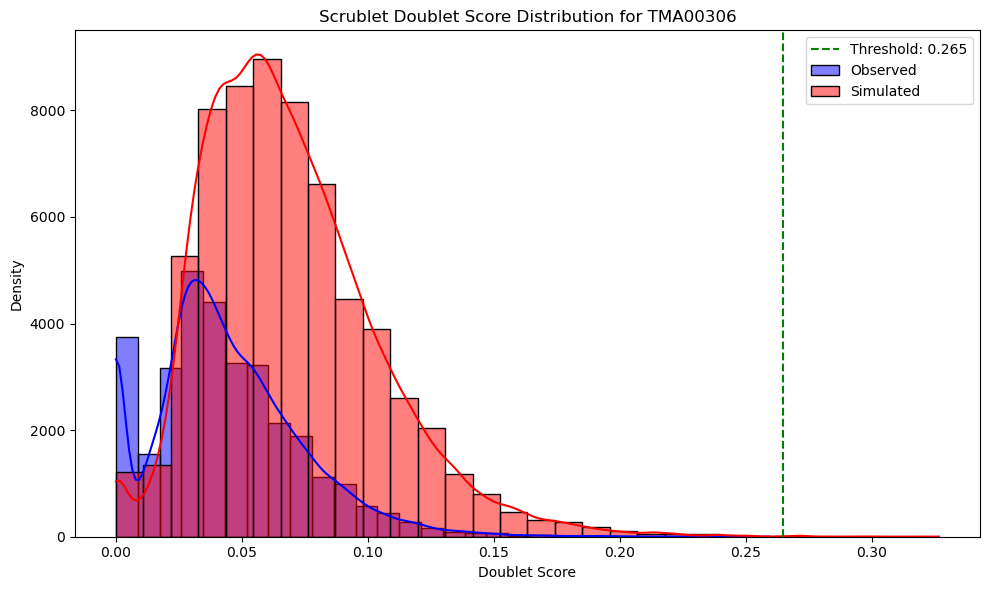

Saved Scrublet CSV for TMA00306 to /home/workspace/projects/drg/scrublet/TMA00306_scrublet_results.csv


In [7]:
print("\n Running Scrublet on whole-cell runs")
run_scrublet(whole_adata_list, scrublet_dir)

print("\n Running Scrublet on nuclear-only runs")
run_scrublet(nuclear_adata_list, scrublet_dir)

## Export

In [8]:
def export_anndata(adata_list, out_dir):
    out_dir = Path(out_dir)  
    for adata in adata_list:
        sample_id = adata.obs["output_id"].iloc[0]
        output_path = out_dir / f"{sample_id}.h5ad"
        adata.write(output_path)
        print(f"Saved filtered AnnData for {sample_id} to {output_path}")


export_anndata(whole_adata_list, output_dirs["whole"])
export_anndata(nuclear_adata_list, output_dirs["nuclear"])

Saved filtered AnnData for TMA00303 to /home/workspace/projects/drg/data/h5ad/export_01/04a_scrublet/whole/TMA00303.h5ad
Saved filtered AnnData for TMA00304 to /home/workspace/projects/drg/data/h5ad/export_01/04a_scrublet/whole/TMA00304.h5ad
Saved filtered AnnData for TMA00305 to /home/workspace/projects/drg/data/h5ad/export_01/04a_scrublet/whole/TMA00305.h5ad
Saved filtered AnnData for TMA00306 to /home/workspace/projects/drg/data/h5ad/export_01/04a_scrublet/whole/TMA00306.h5ad
Saved filtered AnnData for TMA00303 to /home/workspace/projects/drg/data/h5ad/export_01/04b_scrublet/nuclear_only/TMA00303.h5ad
Saved filtered AnnData for TMA00304 to /home/workspace/projects/drg/data/h5ad/export_01/04b_scrublet/nuclear_only/TMA00304.h5ad
Saved filtered AnnData for TMA00305 to /home/workspace/projects/drg/data/h5ad/export_01/04b_scrublet/nuclear_only/TMA00305.h5ad
Saved filtered AnnData for TMA00306 to /home/workspace/projects/drg/data/h5ad/export_01/04b_scrublet/nuclear_only/TMA00306.h5ad


## Session info

In [9]:
print('active IDE: sc-sq')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-sq
active conda environment: sc-scrublet
